In [20]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

BENCHMARK_DIR = "benchmark"

# Auto-discover all benchmark folders
folders = sorted([
    f for f in os.listdir(BENCHMARK_DIR)
    if os.path.isdir(os.path.join(BENCHMARK_DIR, f))
])

# Load data from each folder
data = {}
for folder in folders:
    folder_path = os.path.join(BENCHMARK_DIR, folder)
    records = []
    for fname in os.listdir(folder_path):
        if fname.endswith("concurrency.json"):
            with open(os.path.join(folder_path, fname)) as f:
                records.append(json.load(f))
    records.sort(key=lambda r: r["concurrency"])
    data[folder] = records

print("Loaded folders:", list(data.keys()))
print("Concurrency levels:", [r['concurrency'] for r in list(data.values())[0]])

Loaded folders: ['baseline', 'ecahlang-cudagraph', 'ecahlang-torchcompile', 'sglang', 'vllm']
Concurrency levels: [1, 2, 4, 8, 16, 32, 64, 128]


## Comparison

### First Time Token (TTFT) VS Concurrency

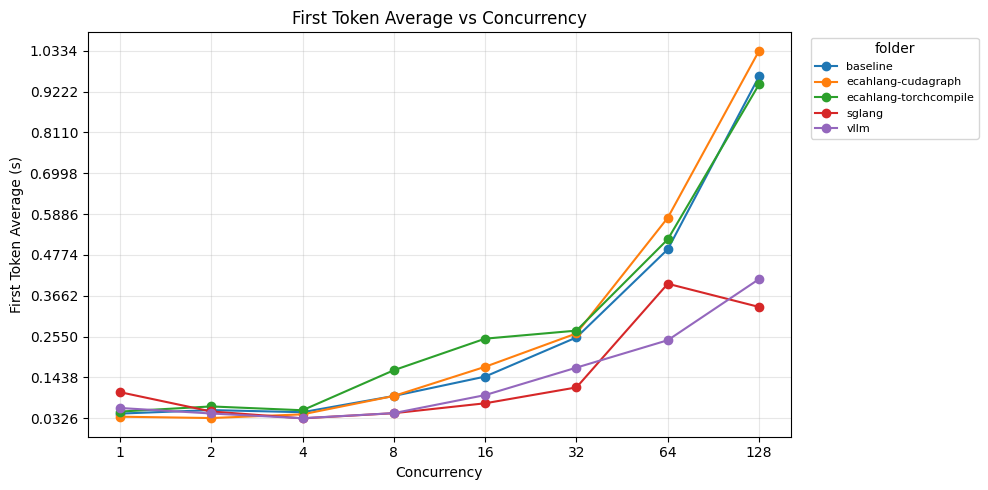

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

x_labels = [str(r["concurrency"]) for r in list(data.values())[0]]
x = np.arange(len(x_labels))

all_vals = []
for folder, records in data.items():
    ttft = [r["avg_ttft_s"] for r in records]
    ax.plot(x, ttft, marker="o", label=folder)
    all_vals.extend(ttft)

ax.set_xlabel("Concurrency")
ax.set_ylabel("First Token Average (s)")
ax.set_title("First Token Average vs Concurrency")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
y_min, y_max = min(all_vals), max(all_vals)
y_ticks = np.linspace(y_min, y_max, 10)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{v:.4f}" for v in y_ticks])
ax.legend(title="folder", fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### End-to-End (E2E) Latency VS Concurrency

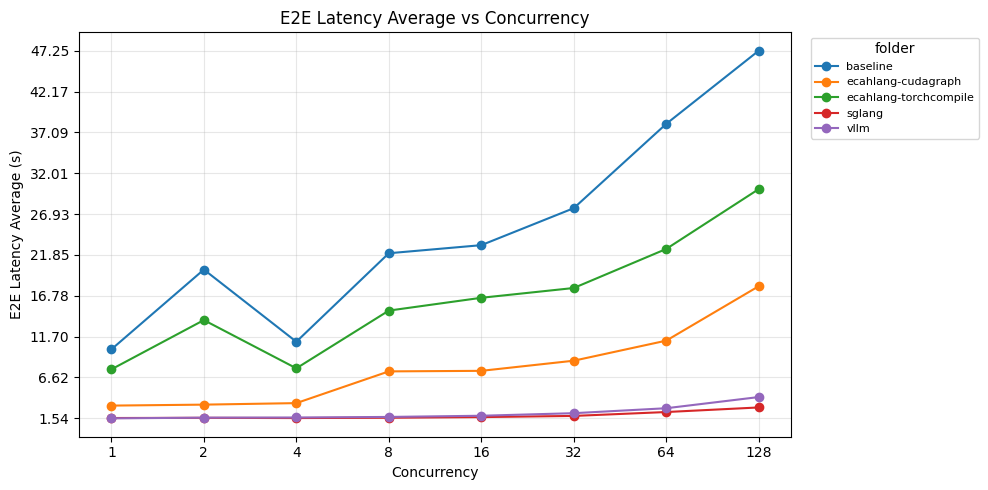

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

x_labels = [str(r["concurrency"]) for r in list(data.values())[0]]
x = np.arange(len(x_labels))

all_vals = []
for folder, records in data.items():
    e2e = [r["avg_e2e_latency_s"] for r in records]
    ax.plot(x, e2e, marker="o", label=folder)
    all_vals.extend(e2e)

ax.set_xlabel("Concurrency")
ax.set_ylabel("E2E Latency Average (s)")
ax.set_title("E2E Latency Average vs Concurrency")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
y_min, y_max = min(all_vals), max(all_vals)
y_ticks = np.linspace(y_min, y_max, 10)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{v:.2f}" for v in y_ticks])
ax.legend(title="folder", fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Inter-Token Latency (ITL) VS Concurrency

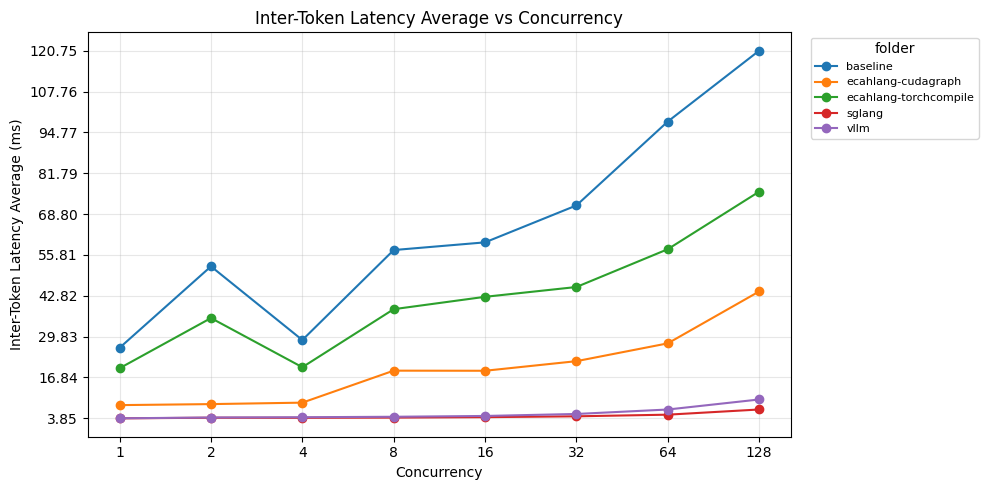

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

x_labels = [str(r["concurrency"]) for r in list(data.values())[0]]
x = np.arange(len(x_labels))

all_vals = []
for folder, records in data.items():
    itl = [r["avg_itl_ms"] for r in records]
    ax.plot(x, itl, marker="o", label=folder)
    all_vals.extend(itl)

ax.set_xlabel("Concurrency")
ax.set_ylabel("Inter-Token Latency Average (ms)")
ax.set_title("Inter-Token Latency Average vs Concurrency")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
y_min, y_max = min(all_vals), max(all_vals)
y_ticks = np.linspace(y_min, y_max, 10)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{v:.2f}" for v in y_ticks])
ax.legend(title="folder", fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()